In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('../data/raw/Resume/Resume.csv')
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Shape: (2484, 4)
Columns: ['ID', 'Resume_str', 'Resume_html', 'Category']


,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


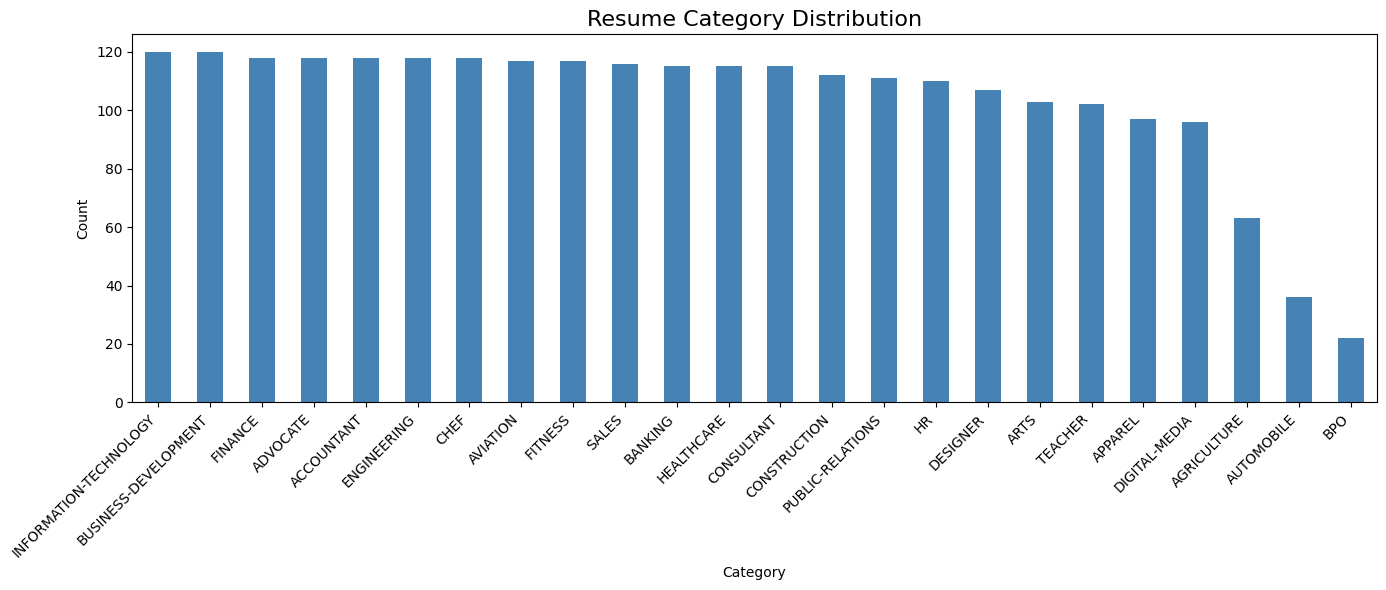

Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
FINANCE                   118
ADVOCATE                  118
ACCOUNTANT                118
ENGINEERING               118
CHEF                      118
AVIATION                  117
FITNESS                   117
SALES                     116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64


In [3]:
plt.figure(figsize=(14, 6))
df['Category'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Resume Category Distribution', fontsize=16)
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../docs/screenshots/category_distribution.png')
plt.show()
print(df['Category'].value_counts())

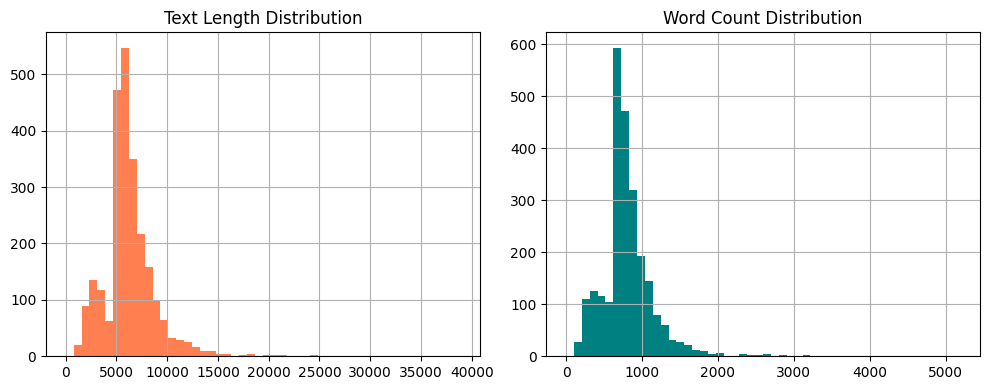

In [4]:
df['text_length'] = df['Resume_str'].apply(len)
df['word_count'] = df['Resume_str'].apply(lambda x: len(x.split()))

plt.figure(figsize=(10, 4))
plt.subplot(1,2,1)
df['text_length'].hist(bins=50, color='coral')
plt.title('Text Length Distribution')
plt.subplot(1,2,2)
df['word_count'].hist(bins=50, color='teal')
plt.title('Word Count Distribution')
plt.tight_layout()
plt.savefig('../docs/screenshots/text_distribution.png')
plt.show()

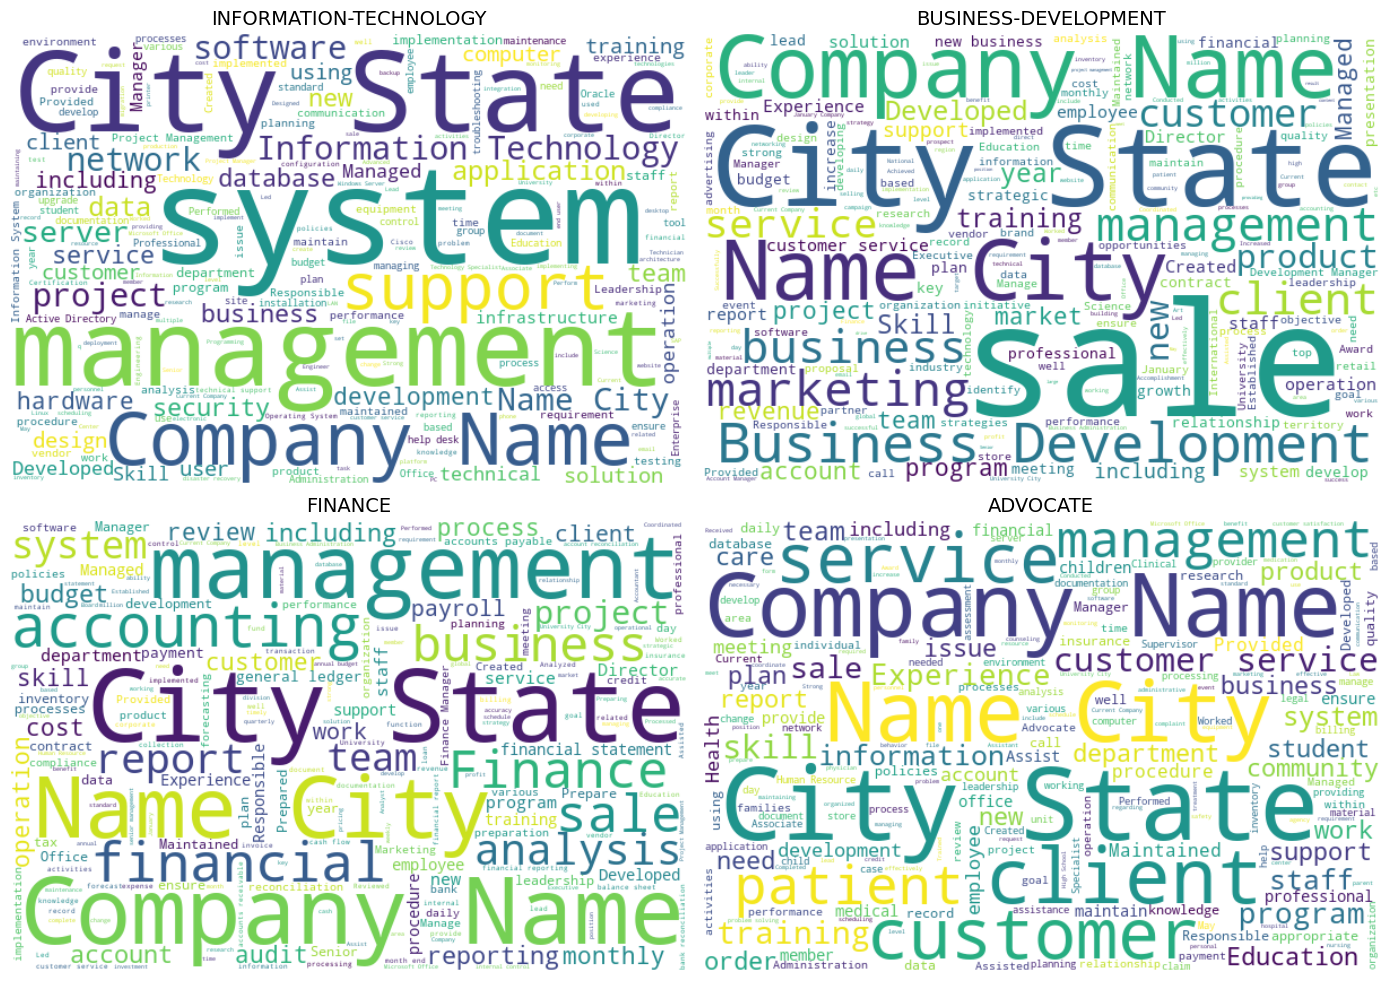

In [5]:
top_cats = df['Category'].value_counts().head(4).index
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, cat in zip(axes.flatten(), top_cats):
    text = ' '.join(df[df['Category'] == cat]['Resume_str'].tolist())
    wc = WordCloud(width=600, height=400, background_color='white').generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(cat, fontsize=14)
    ax.axis('off')

plt.tight_layout()
plt.savefig('../docs/screenshots/wordclouds.png')
plt.show()

In [10]:
import sys
sys.path.append('../backend')
from app.nlp.preprocessor import ResumePreprocessor

preprocessor = ResumePreprocessor()
processed = []

for _, row in df.iterrows():
    result = preprocessor.full_pipeline(row['Resume_str'])
    result['category'] = row['Category']
    processed.append(result)

processed_df = pd.DataFrame(processed)
processed_df.to_csv('../data/processed/resumes_processed.csv', index=False)
print(f"✅ Saved {len(processed_df)} processed resumes!")
processed_df[['category', 'skills', 'education', 'experience_years', 'word_count']].head()

✅ Saved 2484 processed resumes!


,category,skills,education,experience_years,word_count
0,HR,"[go, swift, r, aws, leadership]","[me, high school, college, be]",15.0,658
1,HR,"[go, rust, r, git, communication, project mana...","[master, ba, bachelor, university, be, me, nit]",NaN,707
2,HR,"[go, r, leadership, project management]","[master, ba, institute, nit, bachelor, univers...",20.0,1042
3,HR,"[r, communication]","[me, ba, nit]",NaN,375
4,HR,"[go, r, aws, leadership, teamwork, problem sol...","[ba, bachelor, university, be, me, nit]",NaN,1219
